# Dynamic Dataset Experiments
Statistics and performance charts for the Wikipedia-based dynamic datasets (cpu, disease, actor, single).

In [28]:
from chart_utils import *
import numpy as np
from collections import Counter
import csv as csv_module
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

## Load Data

In [29]:
# ── Dynamic dataset definitions ──────────────────────────────────────────────
DYNAMIC_DATASETS = ["cpu", "disease", "actor", "single","book"] # planet: no added benefit
DYN_DATA_ROOT = dynsbod_root / "datasets/wikipedia/dynfd"
PERTUPLE_ROOT = benchmark_data_path / "dynsbod_results/dynamic_pertuple"
DELETE_FEAT_DYN_ROOT = benchmark_data_path / "dynsbod_results/delete_features_dynamic"

# ── Load per-tuple benchmark metrics ─────────────────────────────────────────
with open(PERTUPLE_ROOT / "benchmark_metrics.json") as f:
    pertuple_metrics = json.load(f)

# ── Load delete-features dynamic benchmark metrics ───────────────────────────
with open(DELETE_FEAT_DYN_ROOT / "benchmark_metrics.json") as f:
    del_feat_dyn_metrics = json.load(f)

# ── algo-idx → config map for delete_features_dynamic ────────────────────────
# Generated by experiments/delete_features.py:
#   for optimizeBuildOrder in [True, False]:
#     for useLazyList in [True, False]:
#       for useEfficientUpdates in [True, False]:
#         DYNAMIC_ALGO_CONFIGS.append(...)
#   DYNAMIC_ALGO_CONFIGS.append({"skipRevalidationByInsert": True})   # algo8

DEL_FEAT_DYN_CONFIG_MAP = {}
idx = 0
for obo in [True, False]:
    for ull in [True, False]:
        for ueu in [True, False]:
            DEL_FEAT_DYN_CONFIG_MAP[str(idx)] = {
                "optimizeBuildOrder": obo,
                "useLazyList": ull,
                "useEfficientUpdates": ueu,
            }
            idx += 1
# algo8 → skipRevalidationByInsert (excluded from chart)

print("DEL_FEAT_DYN_CONFIG_MAP:")
for k, v in DEL_FEAT_DYN_CONFIG_MAP.items():
    print(f"  algo{k}: {v}")

DEL_FEAT_DYN_CONFIG_MAP:
  algo0: {'optimizeBuildOrder': True, 'useLazyList': True, 'useEfficientUpdates': True}
  algo1: {'optimizeBuildOrder': True, 'useLazyList': True, 'useEfficientUpdates': False}
  algo2: {'optimizeBuildOrder': True, 'useLazyList': False, 'useEfficientUpdates': True}
  algo3: {'optimizeBuildOrder': True, 'useLazyList': False, 'useEfficientUpdates': False}
  algo4: {'optimizeBuildOrder': False, 'useLazyList': True, 'useEfficientUpdates': True}
  algo5: {'optimizeBuildOrder': False, 'useLazyList': True, 'useEfficientUpdates': False}
  algo6: {'optimizeBuildOrder': False, 'useLazyList': False, 'useEfficientUpdates': True}
  algo7: {'optimizeBuildOrder': False, 'useLazyList': False, 'useEfficientUpdates': False}


## Dynamic Dataset Statistics Table

In [30]:
def count_csv_col_rows(path):
    """Return (num_data_rows, num_cols) for a CSV file (excluding header row)."""
    with open(path) as f:
        reader = csv_module.reader(f)
        header = next(reader, None)
        if header is None:
            return 0, 0
        rows = sum(1 for _ in reader)
    return rows, len(header)


def count_event_types(path):
    """Count event_type values in an events_with_updates.csv file."""
    counts = Counter()
    with open(path) as f:
        reader = csv_module.DictReader(f)
        for row in reader:
            counts[row.get("event_type", "unknown")] += 1
    return counts


def count_constants_and_compatibles(ds):
    """
    Read n_constants and n_compatibles from the last row of the
    dynsbod intermediate results file for <ds>_final_state.
    Columns used: currentConstantOds, currentComptibleOds.
    Returns (n_constants, n_compatibles) averaged across all runs.
    """
    results_dir = benchmark_data_path / "dynsbod_results/intermediate"
    identifier = f"{ds}_final_state"
    n_constants_list = []
    n_compatibles_list = []
    for file in results_dir.glob(f"*{identifier}*stdout.intermediate.csv"):
        file_str = str(file)
        if '_first_half_' in file_str or '_second_half_' in file_str:
            continue
        try:
            df = pd.read_csv(file)
            if len(df) > 0:
                last_row = df.iloc[-1]
                n_constants_list.append(int(last_row['currentConstantOds']))
                n_compatibles_list.append(int(last_row['currentComptibleOds']))
        except Exception as e:
            print(f"Error reading {file}: {e}")
    if not n_constants_list:
        raise FileNotFoundError(f"No intermediate results found for {identifier}")
    n_constants = round(sum(n_constants_list) / len(n_constants_list))
    n_compatibles = round(sum(n_compatibles_list) / len(n_compatibles_list))
    print(f"{identifier}: {n_constants=}, {n_compatibles=}")
    return n_constants, n_compatibles


def avg_ms(runs, key="total_ms"):
    vals = [r[key] for r in runs if isinstance(r.get(key), (int, float))]
    return float(np.mean(vals)) if vals else None


# ── Collect stats ─────────────────────────────────────────────────────────────
rows_list = []
for ds in DYNAMIC_DATASETS:
    base_dir = DYN_DATA_ROOT / ds
    baseline_csv = base_dir / "baseline.csv"
    events_csv = base_dir / "events_with_updates.csv"

    init_rows, n_cols = count_csv_col_rows(baseline_csv)
    event_counts = count_event_types(events_csv)
    n_inserts = event_counts.get("insert", 0)
    n_updates = event_counts.get("update", 0)
    n_deletes = event_counts.get("delete", 0)
    total_events = sum(event_counts.values())
    # Constants and compatibles from the last row of the final_state intermediate results
    n_constants, n_compatibles = count_constants_and_compatibles(ds)

    # DynSBOD runtime + memory from dynamic_pertuple experiment (algo0 = useEfficientUpdates=True)
    key_eff = f"algo0_java0_{ds}_events_with_updates"
    runs_eff = pertuple_metrics.get(key_eff, [])
    rt_eff  = avg_ms(runs_eff, key="total_ms")
    mem_eff = avg_ms(runs_eff, key="max_mem_mb")

    rows_list.append({
        "Dataset": ds,
        "Columns": n_cols,
        "Initial Rows": init_rows,
        "Inserts": n_inserts,
        "Updates": n_updates,
        # "Deletes": n_deletes,
        # "Total Events": total_events,
        "\\#Final Compatibles": n_compatibles,
        "\\#Final Constants": n_constants,
        "Runtime [s]": f"{rt_eff/1000:.1f}" if rt_eff else "–",
        "Memory [MB]": f"{mem_eff:.0f}" if mem_eff else "–",
    })

stats_df = pd.DataFrame(rows_list)
display(stats_df.set_index("Dataset"))


cpu_final_state: n_constants=436, n_compatibles=6928
disease_final_state: n_constants=0, n_compatibles=364
actor_final_state: n_constants=614, n_compatibles=14913
single_final_state: n_constants=0, n_compatibles=10923
book_final_state: n_constants=0, n_compatibles=28


,Columns,Initial Rows,Inserts,Updates,\#Final Compatibles,\#Final Constants,Runtime [s],Memory [MB]
Dataset,,,,,,,,
cpu,15,61,59,1494,6928,436,68.8,2202
disease,13,2880,2878,25758,364,0,98.5,2787
actor,53,3279,3277,25738,14913,614,–,2085
single,26,21684,21683,531096,10923,0,–,21525
book,16,12625,12623,115038,28,0,402.8,20394


In [31]:
print(stats_df.to_latex(index=False))

\begin{tabular}{lrrrrrrll}
\toprule
Dataset & Columns & Initial Rows & Inserts & Updates & \#Final Compatibles & \#Final Constants & Runtime [s] & Memory [MB] \\
\midrule
cpu & 15 & 61 & 59 & 1494 & 6928 & 436 & 68.8 & 2202 \\
disease & 13 & 2880 & 2878 & 25758 & 364 & 0 & 98.5 & 2787 \\
actor & 53 & 3279 & 3277 & 25738 & 14913 & 614 & – & 2085 \\
single & 26 & 21684 & 21683 & 531096 & 10923 & 0 & – & 21525 \\
book & 16 & 12625 & 12623 & 115038 & 28 & 0 & 402.8 & 20394 \\
\bottomrule
\end{tabular}



## Per-Tuple Operation Runtime Visualization

Average processing time per operation type (insert / update-delete / update-insert), comparing `useEfficientUpdates=True` (algo0) vs `useEfficientUpdates=False` (algo1) across dynamic datasets.

In [32]:
def load_pertuple_csv(ds, algo_idx):
    """
    Load a per-tuple timing CSV for a given dataset and algo index.
    Returns a DataFrame or None if the file does not exist.

    operationType values: 'insert', 'update_delete', 'update_insert'
    """
    fname = PERTUPLE_ROOT / f"algo{algo_idx}_java0_{ds}_events_with_updates_run1_stdout.pertuple.csv"
    if not fname.exists():
        return None
    df = pd.read_csv(fname)
    df["algo"] = algo_idx
    df["dataset"] = ds
    return df


# Collect all per-tuple data
all_pertuple = []
for ds in DYNAMIC_DATASETS:
    for algo_idx in [0, 1]:
        df = load_pertuple_csv(ds, algo_idx)
        if df is not None:
            all_pertuple.append(df)

pertuple_df = pd.concat(all_pertuple, ignore_index=True) if all_pertuple else pd.DataFrame()

# Check available datasets / algo combos
print("Available (dataset, algo) combinations:")
if not pertuple_df.empty:
    print(pertuple_df.groupby(["dataset","algo"])["operationType"].value_counts().to_string())
else:
    print("  (no data)")

Available (dataset, algo) combinations:
dataset  algo  operationType
actor    0     insert             3279
         1     insert             3279
book     0     update_delete    115038
               update_insert    115038
               insert            25248
         1     update_delete    115038
               update_insert    115038
               insert            25248
cpu      0     update_delete      1494
               update_insert      1494
               insert              181
         1     update_delete      1494
               update_insert      1494
               insert              120
disease  0     update_delete     25758
               update_insert     25758
               insert             5758
         1     update_delete     25758
               update_insert     25758
               insert             5758
single   0     insert            21684
         1     insert            21684


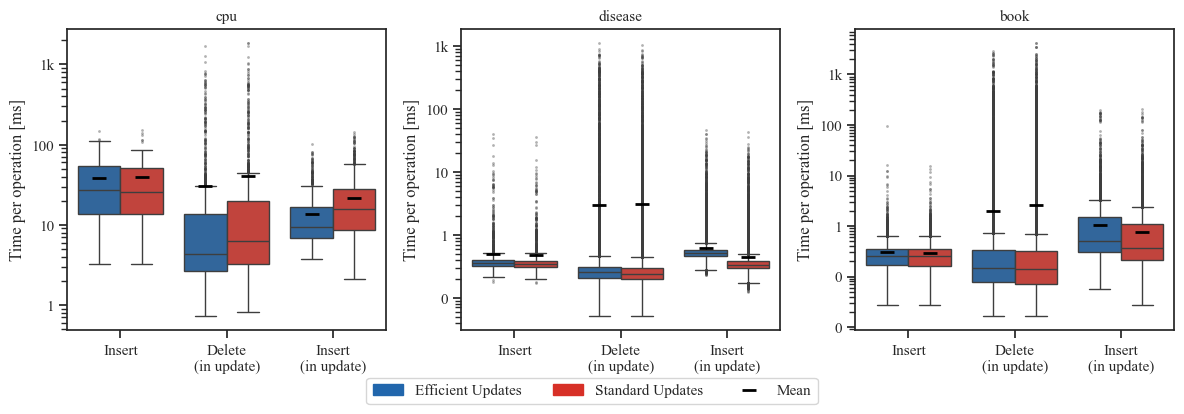

In [33]:
if pertuple_df.empty:
    print("No per-tuple data available.")
else:
    # Pretty labels
    OP_LABELS = {
        "insert": "Insert",
        "update_delete": "Delete\n(in update)",
        "update_insert": "Insert\n(in update)",
    }
    ALGO_LABELS = {
        0: "Efficient Updates",
        1: "Standard Updates",
    }
    ALGO_COLORS = {0: "#2166AC", 1: "#D73027"}

    # Initial row count per dataset (used to exclude baseline inserts)
    initial_rows_by_ds = stats_df.set_index("Dataset")["Initial Rows"].to_dict()

    available_datasets = pertuple_df[pertuple_df["operationType"] == 'update_delete']["dataset"].unique()
    n_ds = len(available_datasets)

    op_order = ["insert", "update_delete", "update_insert"]

    # Prepare data: filter ops, map labels
    plot_df = pertuple_df[pertuple_df["operationType"].isin(op_order)].copy()

    # Exclude initial-load inserts: for "insert" rows, keep only tupleId >= initial row count
    def is_event_row(row):
        if row["operationType"] != "insert":
            return True
        init = initial_rows_by_ds.get(row["dataset"], 0)
        return row["tupleId"] >= init

    plot_df = plot_df[plot_df.apply(is_event_row, axis=1)].copy()

    plot_df["Operation"] = plot_df["operationType"].map(OP_LABELS)
    plot_df["Algorithm"] = plot_df["algo"].map(ALGO_LABELS)
    plot_df["timeMs"] = plot_df["timeMicros"] / 1000.0

    op_label_order = [OP_LABELS[op] for op in op_order]
    algo_label_order = [ALGO_LABELS[a] for a in [0, 1] if a in plot_df["algo"].values]
    palette = {ALGO_LABELS[a]: ALGO_COLORS[a] for a in ALGO_COLORS if ALGO_LABELS[a] in algo_label_order}

    fig, axes = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4), sharey=False)
    if n_ds == 1:
        axes = [axes]

    for ax, ds in zip(axes, available_datasets):
        sub = plot_df[plot_df["dataset"] == ds]
        sns.boxplot(
            data=sub,
            x="Operation",
            y="timeMs",
            hue="Algorithm",
            order=op_label_order,
            hue_order=algo_label_order,
            palette=palette,
            ax=ax,
            flierprops={"marker": ".", "markersize": 2, "alpha": 0.4},
            showmeans=True,
            meanprops={"marker": "_", "markeredgecolor": "black", "markersize": 10, "markeredgewidth": 2},
        )
        # ax.set_xticklabels(op_label_order, rotation=25, ha="right", fontsize=9)
        ax.set_title(ds, fontsize=11)
        ax.set_xlabel("")
        ax.set_yscale("log")
        ax.set_ylabel("Time per operation [ms]")
        ax.yaxis.set_major_formatter(FuncFormatter(human_format))
        ax.get_legend().remove()

    # Shared legend: algo colors + mean marker explanation
    handles = [mpatches.Patch(color=ALGO_COLORS[a], label=ALGO_LABELS[a])
               for a in [0, 1] if a in pertuple_df["algo"].values]
    handles.append(Line2D([0], [0], marker="_", color="black", linestyle="none",
                          markersize=10, markeredgewidth=2, label="Mean"))
    fig.legend(handles=handles, loc="lower center", ncol=len(handles),
               bbox_to_anchor=(0.5, -0.05), frameon=True)

    # plt.suptitle("Per-Tuple Operation Runtimes on Dynamic Datasets", y=1.07, fontsize=13)
    plt.tight_layout()
    save_figure("dynamic_pertuple_operations")
    plt.show()


## Delete Features Graph – Dynamic Datasets

Speedup relative to the baseline configuration (no optimizations) for every combination of
`optimizeBuildOrder`, `lazyList`, and `useEfficientUpdates` on the dynamic (Wikipedia) datasets.

The metric is the **events-processing time** (increment 1 in the benchmark metrics, i.e., everything
after the baseline initial load).  Data comes from `dynsbod_results/delete_features_dynamic`.

In [34]:
# ── Parse delete_features_dynamic metrics ────────────────────────────────────
del_feat_records = []
for combo_key, runs in del_feat_dyn_metrics.items():
    parts = combo_key.split("_")
    algo_version = parts[0].replace("algo", "")
    java_version = parts[1].replace("java", "")
    dataset = "_".join(parts[2:])

    if algo_version not in DEL_FEAT_DYN_CONFIG_MAP:
        continue  # skip algo8+ (skipRevalidationByInsert, not in config map)

    for run_data in runs:
        # events-processing time = increment idx=1
        increments = run_data.get("increments", [])
        events_time_ms = None
        for inc in increments:
            if inc["idx"] == 1:
                events_time_ms = inc.get("time_ms")
                break
        if events_time_ms is None:
            continue

        cfg = DEL_FEAT_DYN_CONFIG_MAP[algo_version]
        del_feat_records.append({
            "algo_version": algo_version,
            "dataset": dataset,
            "events_time_ms": events_time_ms,
            "optimizeBuildOrder": cfg["optimizeBuildOrder"],
            "useLazyList": cfg["useLazyList"],
            "useEfficientUpdates": cfg["useEfficientUpdates"],
        })

del_feat_dyn_df = pd.DataFrame(del_feat_records)
print("Available datasets:", del_feat_dyn_df["dataset"].unique())
print("Algo versions:", sorted(del_feat_dyn_df["algo_version"].unique()))
del_feat_dyn_df.groupby(["dataset", "algo_version"])["events_time_ms"].mean()

Available datasets: ['cpu_events_with_updates' 'disease_events_with_updates'
 'book_events_with_updates']
Algo versions: ['0', '1', '2', '3', '4', '5', '6', '7']


dataset                      algo_version
book_events_with_updates     0               3.475740e+05
                             1               3.845157e+05
                             2               3.823813e+05
                             3               4.272427e+05
                             4               1.337681e+06
                             5               1.629157e+06
                             6               1.342584e+06
                             7               1.627815e+06
cpu_events_with_updates      0               6.524733e+04
                             1               9.820167e+04
                             2               6.240500e+04
                             3               9.476667e+04
                             4               7.157700e+04
                             5               1.003303e+05
                             6               6.905333e+04
                             7               9.977400e+04
disease_events_with_updates  0

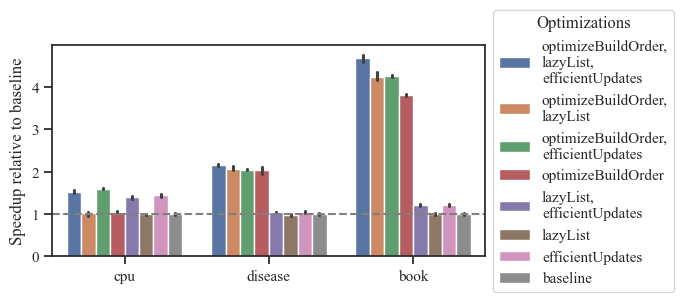

In [35]:
def format_dyn_config_name(row):
    """Human-readable label for a dynamic-dataset optimization config."""
    features = []
    if row["optimizeBuildOrder"]:
        features.append("optimizeBuildOrder")
    if row["useLazyList"]:
        features.append("lazyList")
    if row["useEfficientUpdates"]:
        features.append("efficientUpdates")
    return ",\n".join(features) if features else "baseline"


# ── Aggregate (mean over runs) for baseline computation only ─────────────────
del_feat_agg = (
    del_feat_dyn_df
    .groupby(["dataset", "algo_version", "optimizeBuildOrder", "useLazyList", "useEfficientUpdates"],
             as_index=False)["events_time_ms"]
    .mean()
)

# ── Baseline = algo7 (all False) ──────────────────────────────────────────────
baseline_dyn = (
    del_feat_agg[
        (del_feat_agg["optimizeBuildOrder"] == False)
        & (del_feat_agg["useLazyList"] == False)
        & (del_feat_agg["useEfficientUpdates"] == False)
    ]
    .set_index("dataset")["events_time_ms"]
)

# ── Unaggregated data for barplot (seaborn computes error bars) ───────────────
del_feat_raw = del_feat_dyn_df[del_feat_dyn_df["dataset"].isin(baseline_dyn.index)].copy()
del_feat_raw["relative_runtime"] = del_feat_raw.apply(
    lambda row: baseline_dyn[row["dataset"]] / row["events_time_ms"], axis=1
)
del_feat_raw["Optimizations"] = del_feat_raw.apply(format_dyn_config_name, axis=1)
del_feat_raw["dataset_fmt"] = del_feat_raw["dataset"].apply(
    lambda n: n.replace("_events_with_updates", "")
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(
    data=del_feat_raw,
    x="dataset_fmt",
    y="relative_runtime",
    hue="Optimizations",
    ax=ax,
)
ax.axhline(y=1, color="gray", linestyle="--", linewidth=1.5, label="baseline")
ax.set_xlabel("")
ax.set_ylabel("Speedup relative to baseline")
# plt.xticks(rotation=20, ha="right")
sns.move_legend(ax, "center left", ncols=1, frameon=True,bbox_to_anchor=(1,0.5))
plt.tight_layout()
save_figure("delete_features_dynamic_relative")
plt.show()


In [36]:
del_feat_raw

,algo_version,dataset,events_time_ms,optimizeBuildOrder,useLazyList,useEfficientUpdates,relative_runtime,Optimizations,dataset_fmt
0,0,cpu_events_with_updates,63295,True,True,True,1.576333,"optimizeBuildOrder,\nlazyList,\nefficientUpdates",cpu
1,0,cpu_events_with_updates,66349,True,True,True,1.503775,"optimizeBuildOrder,\nlazyList,\nefficientUpdates",cpu
2,0,cpu_events_with_updates,66098,True,True,True,1.509486,"optimizeBuildOrder,\nlazyList,\nefficientUpdates",cpu
3,1,cpu_events_with_updates,96389,True,True,False,1.035118,"optimizeBuildOrder,\nlazyList",cpu
4,1,cpu_events_with_updates,94707,True,True,False,1.053502,"optimizeBuildOrder,\nlazyList",cpu
...,...,...,...,...,...,...,...,...,...
67,6,book_events_with_updates,1325567,False,False,True,1.228014,efficientUpdates,book
68,6,book_events_with_updates,1363386,False,False,True,1.193950,efficientUpdates,book
69,7,book_events_with_updates,1617674,False,False,False,1.006269,baseline,book
70,7,book_events_with_updates,1597075,False,False,False,1.019247,baseline,book
